In [2]:
# 清理空/无效标签并重新统计 Top10（去除 '', 'nan', 'none', 'null'）
tags["tag"] = tags["tag"].astype(str).str.strip()                          # 统一为字符串并去两端空白
tags = tags[(tags["tag"].str.len() > 0) & (~tags["tag"].str.lower().isin(["nan","none","null"]))]  # 过滤空/无效
top10 = (tags.drop_duplicates(subset=["Id","tag"])
              .groupby("tag", as_index=False)["Id"].nunique()
              .rename(columns={"Id":"dataset_count"})
              .sort_values("dataset_count", ascending=False)
              .head(10))
print(top10)


                        tag  dataset_count
415       pre-trained model          30498
77                 business          27014
159        earth and nature          17261
101        computer science          12007
26   arts and entertainment          11738
516                 tabular          11589
162               education           8809
121          data analytics           8283
253                   image           8064
56                 beginner           8030


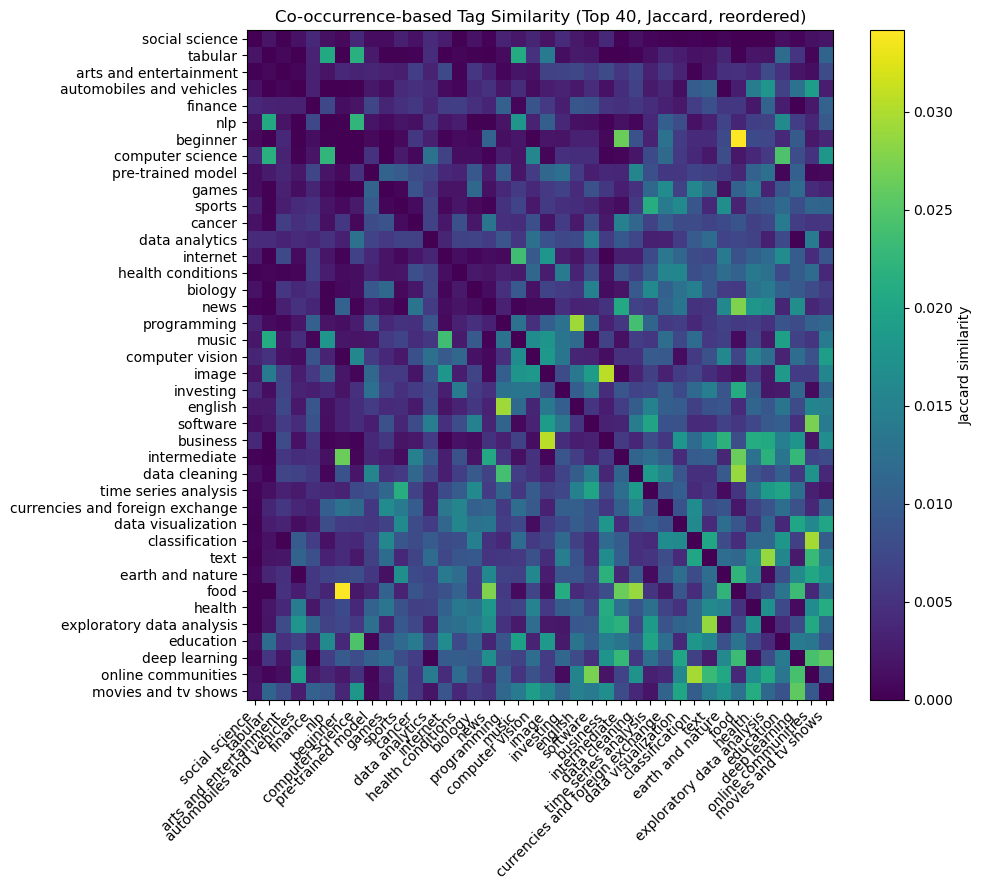

In [6]:
# 阶段｜更清晰的可视化：按“相似标签彼此相邻”的顺序重排，再绘制单张热力图
# 设计要点：
# 1) 仍用 Jaccard (交/并) 衡量“倾向同时出现”，可理解且与规模无关；
# 2) 用矩阵的**第一主方向**（最大特征向量）对标签排序，让相近标签在图上彼此靠近，结构更清晰；
# 3) 只取 Top-K 高频标签，减少噪声（K 可调），并在图上加 colorbar、旋转刻度、去对角；
# 4) 仅使用 matplotlib（不指定配色/风格），满足你之前的绘图约束。

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) 读取数据并拆解标签为长表
df = pd.read_csv("../data/metadata_merged.csv", usecols=["Id","Tags"])
tags = (df.assign(Tags=df["Tags"].fillna(""))
          .assign(tag=df["Tags"].str.split(","))
          .explode("tag"))
tags["tag"] = tags["tag"].astype(str).str.strip()

# 2) 清理空/无效标签（避免 'nan' 文本、空串等）
bad_tokens = {"", "nan", "none", "null"}
tags = tags[~tags["tag"].str.lower().isin(bad_tokens)]

# 3) 选择 Top-K（按覆盖数据集数排序）以保证图的可读性
K = 40  # 你可改为 20/30/60 等
top_tags = (tags.drop_duplicates(["Id","tag"])
                 .groupby("tag")["Id"].nunique()
                 .sort_values(ascending=False)
                 .head(K)
                 .index.tolist())

# 4) 构造 0/1 指示矩阵（数据集 × 标签），并计算 Jaccard 相似度矩阵
tags_top = tags[tags["tag"].isin(top_tags)].drop_duplicates(["Id","tag"])
X = pd.crosstab(tags_top["Id"], tags_top["tag"]).astype(np.uint8)  # 行=Id，列=tag
X = (X > 0).astype(np.uint8)                                       # 保底转 0/1

co = X.T.dot(X).astype(np.int32)                                   # 共现次数矩阵 |A∩B|
np.fill_diagonal(co.values, 0)                                     # 去对角（自共现无意义）
ni = X.sum(axis=0).to_numpy().astype(np.int32)                     # 每个标签覆盖 |A|
union = ni[:,None] + ni[None,:] - co.to_numpy()                    # 并集 |A∪B| = |A|+|B|-|A∩B|
with np.errstate(divide="ignore", invalid="ignore"):
    jacc = np.where(union > 0, co.to_numpy() / union, 0.0)         # Jaccard 相似度

# 5) 用“第一主方向”对标签排序：让相似标签在热力图上彼此相邻（更清晰）
#    对称矩阵可用特征分解；取最大特征向量对索引排序
w, v = np.linalg.eigh((jacc + jacc.T) / 2.0)                       # 保守对称化
order = np.argsort(v[:, -1])                                       # 最大特征值对应的特征向量
tags_ordered = np.array(top_tags)[order]
jacc_ord = jacc[order][:, order]

# 6) 绘制：单图、添加 colorbar、旋转刻度、紧凑布局
fig = plt.figure(figsize=(10, 9))
plt.imshow(jacc_ord, aspect="auto")                                 # 不设颜色方案，遵循默认
plt.colorbar(label="Jaccard similarity")                            # 颜色条指示相似度大小
plt.xticks(range(len(tags_ordered)), tags_ordered, rotation=45, ha="right")
plt.yticks(range(len(tags_ordered)), tags_ordered)
plt.title(f"Co-occurrence-based Tag Similarity (Top {K}, Jaccard, reordered)")
plt.tight_layout()
plt.show()


In [8]:
# 阶段｜用“简单语义模型”对 tag 做分组，并统计每组覆盖的数据集数量（降序显示前10）
# 思路：
# 1) 读取 Id、Tags；拆成一行一个 tag，清理空/无效项
# 2) 用 TF-IDF（词/二元词组）把“tag 文本”转成向量；KMeans 做粗粒度语义分组（K 可调）
# 3) 把“tag→cluster”并回到明细，按 cluster 统计“覆盖的唯一数据集数”；打印前10
# 备注：这是“轻量语义”的近似做法，适合离线/无 API 的环境

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# 1) 读取并拆标签；清理空/无效标签
df = pd.read_csv("../data/metadata_merged.csv", usecols=["Id","Tags"])
tags = (df.assign(Tags=df["Tags"].fillna(""))
          .assign(tag=df["Tags"].str.split(","))
          .explode("tag"))
tags["tag"] = tags["tag"].astype(str).str.strip()
bad = {"", "nan", "none", "null"}
tags = tags[~tags["tag"].str.lower().isin(bad)]

# 2) 语义向量化 + 聚类：对“唯一 tag 文本”做 TF-IDF → KMeans
unique_tags = sorted(tags["tag"].unique().tolist())
K = 20  # 你可调小(10/15)或调大(30/40)；越大分组越细
vec = TfidfVectorizer(analyzer="word", ngram_range=(1,2), min_df=1)
X = vec.fit_transform(unique_tags)
km = KMeans(n_clusters=K, n_init=10, random_state=42)
labels = km.fit_predict(X)

# 3) 建立 tag→cluster 映射，并回并到明细表
tag2cluster = pd.DataFrame({"tag": unique_tags, "cluster": labels})
tags = tags.merge(tag2cluster, how="left", on="tag")

# 4) 统计每个 cluster 覆盖的“唯一数据集数”，并给出示例标签帮助理解
grp = (tags.drop_duplicates(subset=["Id","tag"])              # 防止同数据集重复计入同一标签
           .groupby("cluster")
           .agg(dataset_count=("Id","nunique")))
# 为每个 cluster 取几个最常见的代表标签（按覆盖数据集数排序）
top_tag_examples = (tags.groupby(["cluster","tag"])["Id"].nunique()
                        .sort_values(ascending=False)
                        .groupby(level=0)
                        .head(6)                              # 每组取前6个代表标签
                        .reset_index()
                        .groupby("cluster")["tag"]
                        .apply(lambda s: ", ".join(s.tolist()))
                        .to_frame("example_tags"))

out = (grp.join(top_tag_examples)
          .sort_values("dataset_count", ascending=False)
          .reset_index()
          .head(10))
print(out)


   cluster  dataset_count                                       example_tags
0       15         170125  pre-trained model, business, tabular, educatio...
1        7          62126  earth and nature, arts and entertainment, movi...
2        3          21971  computer science, computer vision, social scie...
3       16          16172  data analytics, data visualization, explorator...
4       12           9439  classification, image classification, binary c...
5        1           8668  image, image segmentation, segmentation, image...
6        2           8430  text, text mining, text generation, text pre-p...
7        4           3170  video games, video, video classification, vide...
8       17           1255                      cnn, faster r-cnn, mask r-cnn
9        8            940  object detection, image text detection, pose d...


In [11]:
# 阶段｜用“语义模型（TF-IDF + KMeans）”为每个簇选出代表性 tag（最接近簇心的tag）
# 思路：
# 1) 仍用 TF-IDF 向量化 tag 文本 + KMeans 聚类（简易语义模型）；
# 2) 对每个簇，取“与该簇质心最相似（余弦最大）”的 tag 作为代表性 tag；
# 3) 统计每簇覆盖的数据集数，并给出若干示例 tag；最后打印结果（含 rep_tag）。

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

# 读取与清洗：拆成一行一个 tag，去掉空/无效
df = pd.read_csv("../data/metadata_merged.csv", usecols=["Id","Tags"])
tags = (df.assign(Tags=df["Tags"].fillna("")).assign(tag=df["Tags"].str.split(",")).explode("tag"))
tags["tag"] = tags["tag"].astype(str).str.strip()
bad = {"", "nan", "none", "null"}
tags = tags[~tags["tag"].str.lower().isin(bad)]

# 语义向量化 + 聚类（你可调整 K 的粒度）
unique_tags = sorted(tags["tag"].unique().tolist())
K = 20
vec = TfidfVectorizer(analyzer="word", ngram_range=(1,2), min_df=1)
X = vec.fit_transform(unique_tags)                  # 稀疏 TF-IDF（默认 L2 归一化）
km = KMeans(n_clusters=K, n_init=10, random_state=42)
labels = km.fit_predict(X)

# 代表性 tag：对每个簇，找与簇心最相似（余弦最大）的 tag
centers = km.cluster_centers_.copy()
centers /= (np.linalg.norm(centers, axis=1, keepdims=True) + 1e-12)  # 归一化簇心
rep = []
for c in range(K):
    idx = np.where(labels == c)[0]                   # 属于簇 c 的 tag 索引
    if idx.size == 0:
        rep.append((c, None))
        continue
    sims = X[idx].dot(centers[c])                    # 稀疏矩阵 × 向量 → 余弦相似度
    best = idx[np.asarray(sims).ravel().argmax()]    # 选最大相似度的 tag
    rep.append((c, unique_tags[best]))
rep_tags = pd.DataFrame(rep, columns=["cluster","rep_tag"])

# 回并聚合：每簇覆盖的数据集数 + 若干示例 tag（便于理解该簇语义）
tag2cluster = pd.DataFrame({"tag": unique_tags, "cluster": labels})
tags = tags.merge(tag2cluster, how="left", on="tag")

grp = (tags.drop_duplicates(["Id","tag"])
           .groupby("cluster")
           .agg(dataset_count=("Id","nunique")))

examples = (tags.groupby(["cluster","tag"])["Id"].nunique()
               .sort_values(ascending=False)
               .groupby(level=0).head(6)            # 每簇取 6 个代表性示例
               .reset_index()
               .groupby("cluster")["tag"]
               .apply(lambda s: ", ".join(s.tolist()))
               .to_frame("example_tags"))

out = (grp.join(examples).reset_index()
          .merge(rep_tags, on="cluster", how="left")
          .sort_values("dataset_count", ascending=False))

print(out.head(10))  # 展示前10个簇（包含：cluster, dataset_count, example_tags, rep_tag）


    cluster  dataset_count                                       example_tags  \
15       15         170125  pre-trained model, business, tabular, educatio...   
7         7          62126  earth and nature, arts and entertainment, movi...   
3         3          21971  computer science, computer vision, social scie...   
16       16          16172  data analytics, data visualization, explorator...   
12       12           9439  classification, image classification, binary c...   
1         1           8668  image, image segmentation, segmentation, image...   
2         2           8430  text, text mining, text generation, text pre-p...   
4         4           3170  video games, video, video classification, vide...   
17       17           1255                      cnn, faster r-cnn, mask r-cnn   
8         8            940  object detection, image text detection, pose d...   

                    rep_tag  
15                   health  
7        health and fitness  
3          compute

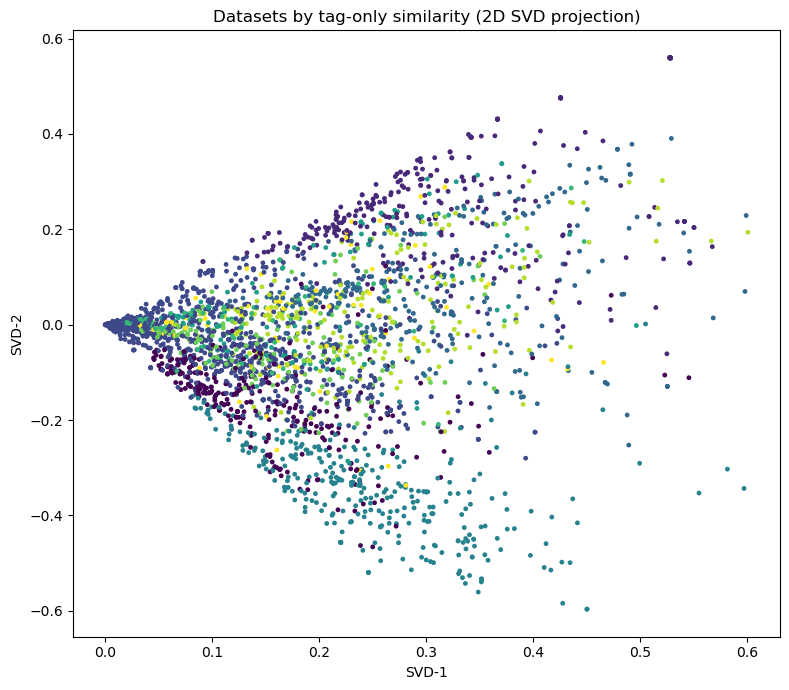

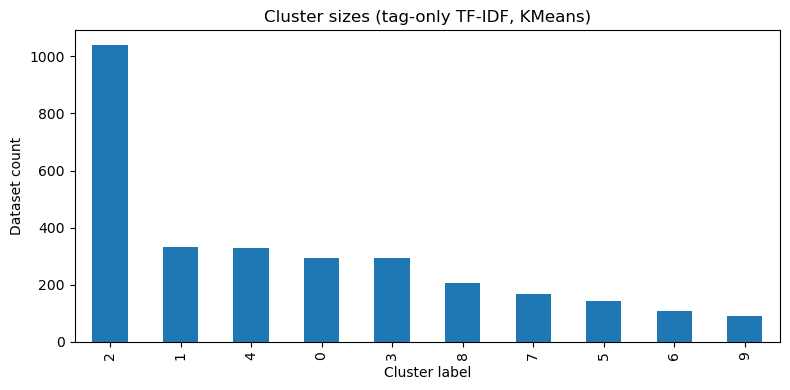

    anchor_id                    anchor_title  neighbor_id  \
10         19                    Iris Species      3701557   
11         19                    Iris Species       130737   
12         19                    Iris Species        78313   
13         19                    Iris Species         1810   
14         19                    Iris Species         1260   
15         19                    Iris Species        51982   
16         19                    Iris Species        17860   
17         19                    Iris Species      2702329   
18         19                    Iris Species       456014   
19         19                    Iris Species      2539169   
30        228  Pima Indians Diabetes Database         2672   
31        228  Pima Indians Diabetes Database        23651   
32        228  Pima Indians Diabetes Database         2319   
33        228  Pima Indians Diabetes Database          478   
34        228  Pima Indians Diabetes Database         3724   
35      

In [13]:
# === Tag-only 语义相似度：TF-IDF + 余弦 + KMeans + SVD 可视化 ===
# 输出：
#  (1) 图：2D 散点（按聚类着色）；(2) 图：簇规模柱状图；(3) 表：若干“锚点数据集”的相似邻居清单
# 仅用 scikit-learn / matplotlib（无需联网下载模型）

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.neighbors import NearestNeighbors
from math import sqrt

# 1) 读取数据（只需这几列；若没有 TotalDownloads 会自动置0）
df = pd.read_csv("../data/metadata_merged.csv", low_memory=False)
for c in ["Id", "Title", "Tags"]:
    assert c in df.columns, f"缺少必要列：{c}"
if "TotalDownloads" not in df.columns:
    df["TotalDownloads"] = 0

ds = df[["Id","Title","Tags","TotalDownloads"]].copy()

# 2) 预处理：把逗号分隔的标签拆成列表，并清洗/去重（按数据集内部）
def split_clean(tags):
    if pd.isna(tags) or not str(tags).strip():
        return []
    toks = [t.strip().lower() for t in str(tags).split(",")]
    toks = [t for t in toks if t and t not in {"nan","none","null"}]
    # 数据集内部去重（保序）
    seen, out = set(), []
    for t in toks:
        if t not in seen:
            seen.add(t); out.append(t)
    return out

ds["tag_list"] = ds["Tags"].apply(split_clean)
ds = ds[ds["tag_list"].map(len) > 0].reset_index(drop=True)

# 3) 为了图和NN演示可控，抽取一个适度样本（优先按下载量前 N）
N_TARGET = 3000
if len(ds) > N_TARGET:
    ds = ds.sort_values("TotalDownloads", ascending=False).head(N_TARGET).copy().reset_index(drop=True)

# 4) 用 TF-IDF 对 tag 列表向量化（传入预分词的列表）
vec = TfidfVectorizer(
    tokenizer=lambda x: x, preprocessor=lambda x: x,
    token_pattern=None, lowercase=False, ngram_range=(1,1), min_df=2
)
X = vec.fit_transform(ds["tag_list"])  # 稀疏矩阵

# 5) 聚类与降维（K 自动随样本量变化，SVD 2D 可视化）
K = int(max(5, min(25, round(sqrt(max(50, X.shape[0]) / 30)))))  # 5~25 的经验范围
kmeans = KMeans(n_clusters=K, n_init=10, random_state=42)
labels = kmeans.fit_predict(X)

svd = TruncatedSVD(n_components=2, random_state=42)
coords = svd.fit_transform(X)

# 6) 图1：2D 散点（按簇上色）
plt.figure(figsize=(8,7))
plt.scatter(coords[:,0], coords[:,1], s=6, c=labels)  # 使用默认配色；不显式指定颜色
plt.title("Datasets by tag-only similarity (2D SVD projection)")
plt.xlabel("SVD-1"); plt.ylabel("SVD-2")
plt.tight_layout(); plt.show()

# 7) 图2：簇规模柱状图
cluster_sizes = pd.Series(labels).value_counts().sort_values(ascending=False)
plt.figure(figsize=(8,4))
cluster_sizes.plot(kind="bar")
plt.title("Cluster sizes (tag-only TF-IDF, KMeans)")
plt.xlabel("Cluster label"); plt.ylabel("Dataset count")
plt.tight_layout(); plt.show()

# 8) 最近邻检索（基于余弦距离）：给若干“锚点数据集”找前10个相似邻居
nn = NearestNeighbors(metric="cosine", n_neighbors=min(11, len(ds)))  # 包含自己 + 10邻居
nn.fit(X)

anchors = ds.sort_values("TotalDownloads", ascending=False).head(min(5, len(ds))).copy()
anchor_idx = anchors.index.to_numpy()

rows = []
for idx in anchor_idx:
    distances, indices = nn.kneighbors(X[idx], return_distance=True)
    distances, indices = distances.ravel(), indices.ravel()
    for d, j in zip(distances[1:11], indices[1:11]):  # 跳过自身
        sim = float(1.0 - d)
        shared = len(set(ds.loc[idx,"tag_list"]).intersection(ds.loc[j,"tag_list"]))
        rows.append({
            "anchor_id":    int(ds.loc[idx,"Id"]),
            "anchor_title": str(ds.loc[idx,"Title"]),
            "neighbor_id":  int(ds.loc[j,"Id"]),
            "neighbor_title": str(ds.loc[j,"Title"]),
            "similarity(tag-only)": round(sim, 4),
            "shared_tags":  shared,
            "neighbor_tags": ", ".join(ds.loc[j,"tag_list"][:12]),
        })

nn_table = pd.DataFrame(rows).sort_values(
    ["anchor_id","similarity(tag-only)","shared_tags"], ascending=[True, False, False]
)

# 打印前若干行预览；如需保存可取消下面一行注释
print(nn_table.head(30))
# nn_table.to_csv("./data/tag_only_neighbors.csv", index=False)


In [15]:
# 阶段｜打印 SVD 两个主方向的“高载荷标签”
# 作用：
# - 仅基于 Tags（逗号分隔）重新构建 TF-IDF
# - TruncatedSVD(n_components=2) 拟合后，列出：
#   · SVD-1（第一主方向）的前 15 个正载荷标签（理解“通用方向/主轴”）
#   · SVD-2 的前 15 个正载荷标签 & 前 15 个负载荷标签（理解两个分叉主题）
# 说明：SVD 的符号可能整体翻转，解读看“成分载荷最大的标签语义”。

import pandas as pd, numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# 1) 读取并把逗号分隔的 tag 清洗为列表；去空/去 'nan'/'none'/'null'；列表内去重（保序）
df = pd.read_csv("../data/metadata_merged.csv", usecols=["Tags"], low_memory=False)
bad = {"", "nan", "none", "null"}
df["tag_list"] = (
    df["Tags"].fillna("")
      .apply(lambda s: [t.strip().lower() for t in str(s).split(",")])
      .apply(lambda xs: [t for t in xs if t not in bad])
      .apply(lambda xs: list(dict.fromkeys(xs)))           # 数据集内部去重（保序）
)
df = df[df["tag_list"].map(len) > 0].reset_index(drop=True)

# 2) 用“预分词输入”方式做 TF-IDF（min_df=2 去掉只出现过一次的稀有标签）
vec = TfidfVectorizer(tokenizer=lambda x: x, preprocessor=lambda x: x,
                      token_pattern=None, lowercase=False, ngram_range=(1,1), min_df=2)
X = vec.fit_transform(df["tag_list"])
feat = np.array(vec.get_feature_names_out())

# 3) 拟合 2 维 SVD，并取成分载荷（components_ 的形状：2 × |V|）
svd = TruncatedSVD(n_components=2, random_state=42)
svd.fit(X)
comp1, comp2 = svd.components_[0], svd.components_[1]

# 4) 取前 15 个高载荷标签（SVD-1 正向）
idx1_pos = np.argsort(comp1)[::-1][:15]
print("\n=== SVD-1（第一主方向）Top +15 载荷标签 ===")
print(pd.DataFrame({"tag": feat[idx1_pos], "weight": comp1[idx1_pos]}))

# 5) SVD-2 的两端：正向与负向各 15 个（帮助理解“两个分叉”的语义）
idx2_pos = np.argsort(comp2)[::-1][:15]
idx2_neg = np.argsort(comp2)[:15]
print("\n=== SVD-2 Top +15 载荷标签（上分支） ===")
print(pd.DataFrame({"tag": feat[idx2_pos], "weight": comp2[idx2_pos]}))
print("\n=== SVD-2 Top -15 载荷标签（下分支） ===")
print(pd.DataFrame({"tag": feat[idx2_neg], "weight": comp2[idx2_neg]}))



=== SVD-1（第一主方向）Top +15 载荷标签 ===
                         tag    weight
0          pre-trained model  0.999553
1     arts and entertainment  0.014223
2                   business  0.013056
3           earth and nature  0.012401
4   clothing and accessories  0.011494
5           computer science  0.008319
6                        law  0.007177
7                   exercise  0.007041
8                  education  0.003741
9                     health  0.002625
10  automobiles and vehicles  0.002347
11                   biology  0.002175
12                     music  0.001977
13                  software  0.001889
14      standardized testing  0.001888

=== SVD-2 Top +15 载荷标签（上分支） ===
                          tag    weight
0                    business  0.996436
1            earth and nature  0.044451
2                   investing  0.040995
3                     finance  0.028186
4            computer science  0.016753
5                   education  0.015690
6                     tabular

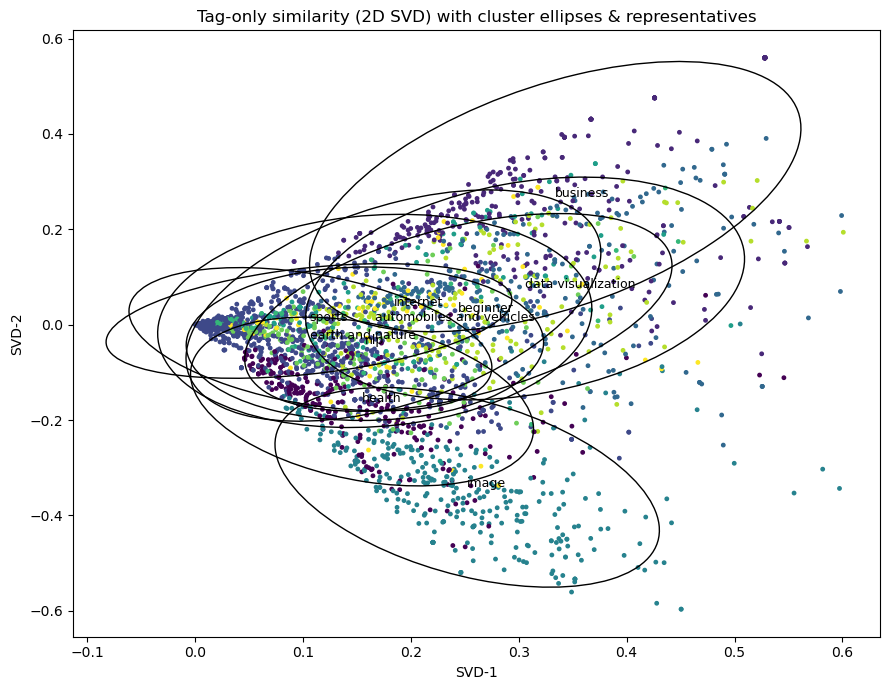

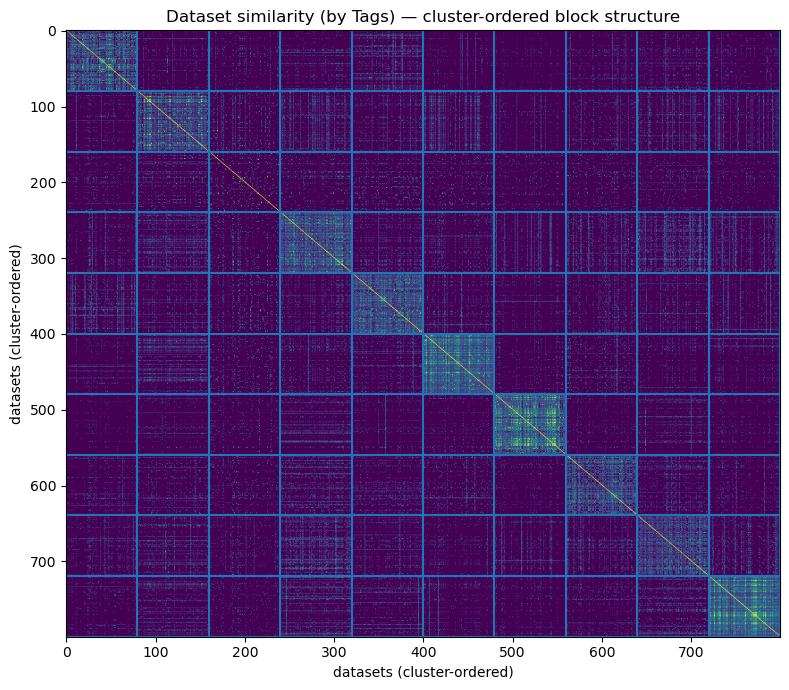

In [16]:
# === 更清晰的区块展示：椭圆边界 + 按簇重排的相似度块图 ===
# 仅用 TF-IDF(基于 Tags) + KMeans + SVD；可直接运行生成两张图
# 注意：不指定颜色；每张图单独绘制

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from math import sqrt

# ---------- 1) 读取与预处理 ----------
df = pd.read_csv("../data/metadata_merged.csv", usecols=["Id","Title","Tags","TotalDownloads"], low_memory=False)
if "TotalDownloads" not in df.columns:
    df["TotalDownloads"] = 0

def split_clean(tags):
    if pd.isna(tags) or not str(tags).strip():
        return []
    toks = [t.strip().lower() for t in str(tags).split(",")]
    toks = [t for t in toks if t and t not in {"nan","none","null"}]
    # 数据集内部去重（保序）
    seen, out = set(), []
    for t in toks:
        if t not in seen:
            seen.add(t); out.append(t)
    return out

ds = df.copy()
ds["tag_list"] = ds["Tags"].apply(split_clean)
ds = ds[ds["tag_list"].map(len) > 0].reset_index(drop=True)

# 控制规模用于作图（优先热门）
N_TARGET = 3000
if len(ds) > N_TARGET:
    ds = ds.sort_values("TotalDownloads", ascending=False).head(N_TARGET).reset_index(drop=True)

# ---------- 2) TF-IDF 向量化 + 聚类 + 2D 投影 ----------
vec = TfidfVectorizer(tokenizer=lambda x: x, preprocessor=lambda x: x,
                      token_pattern=None, lowercase=False, ngram_range=(1,1), min_df=2)
X = vec.fit_transform(ds["tag_list"])               # 稀疏 TF-IDF（默认 L2 归一化）

K = int(max(5, min(25, round(sqrt(max(50, X.shape[0]) / 30)))))  # 经验范围 5~25
kmeans = KMeans(n_clusters=K, n_init=10, random_state=42)
labels = kmeans.fit_predict(X)

svd = TruncatedSVD(n_components=2, random_state=42)
coords = svd.fit_transform(X)                       # (n,2) 作为散点的坐标

# 代表性标签（用于标注）：取每个簇中心在特征空间上的最大权重标签
feat = np.array(vec.get_feature_names_out())
rep_tags = []
centers = kmeans.cluster_centers_
for c in range(K):
    top_idx = np.argsort(centers[c])[::-1][:1]      # 取1个代表标签（也可以取前3个）
    rep_tags.append(", ".join(feat[top_idx]))

# ---------- 3) 图一：散点 + 椭圆区块边界 + 代表性标签 ----------
plt.figure(figsize=(9, 7))
plt.scatter(coords[:,0], coords[:,1], s=6, c=labels)   # 默认配色；不显式设色

# 为每个簇画协方差椭圆（约 2 标准差范围）
for c in range(K):
    pts = coords[labels == c]
    if len(pts) < 3:
        continue
    mu = pts.mean(axis=0)
    cov = np.cov(pts.T)
    # 特征分解得到主轴方向与长度
    vals, vecs = np.linalg.eigh(cov)
    order = np.argsort(vals)[::-1]
    vals, vecs = vals[order], vecs[:,order]
    angle = np.degrees(np.arctan2(vecs[1,0], vecs[0,0]))
    width, height = 2 * 2 * np.sqrt(vals)          # 2*std 的直径；系数可调大些使边界更清晰
    ell = Ellipse(xy=mu, width=width, height=height, angle=angle, fill=False)
    plt.gca().add_patch(ell)
    # 在椭圆中心偏移处标注代表性标签（避免文字与点重叠可加微小偏移）
    plt.text(mu[0], mu[1], rep_tags[c], fontsize=9)

plt.title("Tag-only similarity (2D SVD) with cluster ellipses & representatives")
plt.xlabel("SVD-1"); plt.ylabel("SVD-2"); plt.tight_layout(); plt.show()

# ---------- 4) 图二：按簇重排的相似度块图（清晰的区块分隔） ----------
# 为了避免 O(n^2) 过大，分簇等量抽样（每簇最多 M 个）
M = 80  # 每簇抽样上限；总样本约 ≤ K*M
take_idx = []
for c in range(K):
    cand = np.where(labels == c)[0]
    if len(cand) > M:
        # 这里按下载量优先抽样
        cand = cand[np.argsort(ds.loc[cand, "TotalDownloads"].to_numpy())[::-1][:M]]
    take_idx.extend(cand.tolist())

take_idx = np.array(take_idx, dtype=int)
X_sub = X[take_idx]                            # 稀疏 (m, d)
labs_sub = labels[take_idx]
ids_sub = ds.loc[take_idx, "Id"].to_numpy()

# 计算相似度并按簇排序
order = np.argsort(labs_sub)                   # 先按簇编号排序
X_ord = X_sub[order]
labs_ord = labs_sub[order]
ids_ord = ids_sub[order]

# 稀疏×稀疏 → 稠密相似度矩阵（m×m），规模由 M 和 K 控制
S = (X_ord @ X_ord.T).toarray()                # 余弦相似度（TF-IDF 默认 L2 归一）

plt.figure(figsize=(8, 7))
plt.imshow(S, aspect="auto")                   # 默认配色；不显式设色
plt.title("Dataset similarity (by Tags) — cluster-ordered block structure")
plt.xlabel("datasets (cluster-ordered)"); plt.ylabel("datasets (cluster-ordered)")

# 画分隔线：在簇边界处加线，形成清晰“块状对角”
bounds = []
start = 0
for c in range(K):
    size = int((labs_ord == c).sum())
    if size == 0: 
        continue
    end = start + size
    bounds.append(end)
    # 横纵同时画，形成方块边界
    plt.axhline(end - 0.5)
    plt.axvline(end - 0.5)
    start = end

plt.tight_layout(); plt.show()


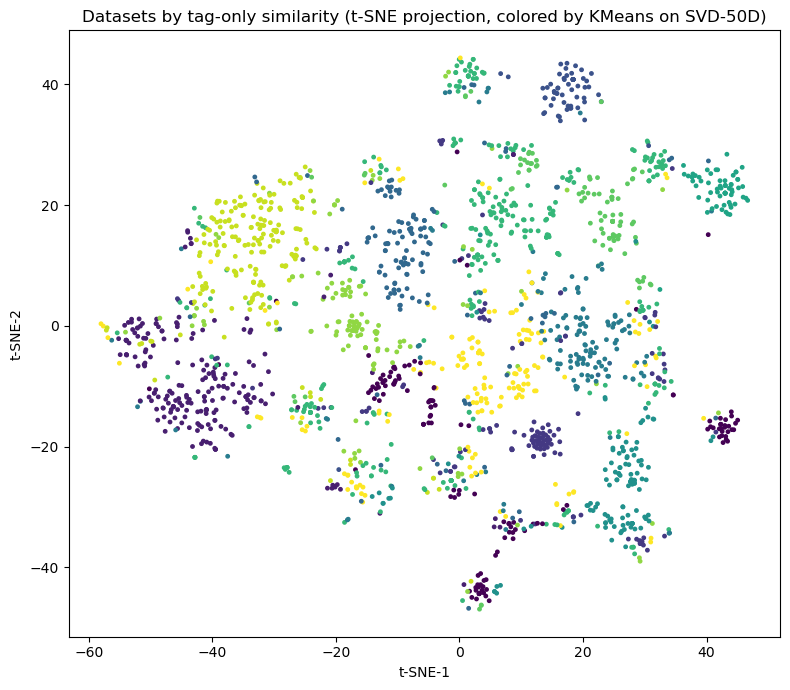

Cluster sizes (by label):
0     138
1     204
2     144
3      66
4     143
5     147
6     121
7      66
8     356
9     104
10    132
11    201
12    178


In [22]:
# 用 t-SNE 让“团块”自然显现，并按聚簇着色（不手动设定颜色方案）
# 流程：读取 → 清洗 tag → TF-IDF → SVD(50d) → KMeans(在 50 维上) → t-SNE(2d) → 散点图 c=labels
# 兼容较老版本 sklearn 的 TSNE 参数；仅使用 matplotlib 画图

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

# 1) 读取所需列；若无 TotalDownloads 列则置 0（用于抽样）
df = pd.read_csv("../data/metadata_merged.csv", low_memory=False)
if "TotalDownloads" not in df.columns:
    df["TotalDownloads"] = 0

# 2) 清洗 Tags → 列表；小写、去空/无效词、数据集内部去重
bad = {"", "nan", "none", "null"}
df["tag_list"] = (
    df["Tags"].fillna("")
      .apply(lambda s: [t.strip().lower() for t in str(s).split(",")])
      .apply(lambda xs: [t for t in xs if t not in bad])
      .apply(lambda xs: list(dict.fromkeys(xs)))    # 保序去重
)
df = df[df["tag_list"].map(len) > 0].reset_index(drop=True)

# 3) 控制规模（t-SNE 复杂度 O(n^2)）：优先抽取热门的前 N 个
N = 2000
if len(df) > N:
    df = df.sort_values("TotalDownloads", ascending=False).head(N).reset_index(drop=True)

# 4) TF-IDF（预分词输入；min_df=2 过滤极稀有标签）
vec = TfidfVectorizer(
    tokenizer=lambda x: x, preprocessor=lambda x: x,
    token_pattern=None, lowercase=False, min_df=2
)
X = vec.fit_transform(df["tag_list"])   # 稀疏 TF-IDF（默认 L2 归一）

# 5) SVD 降到 50 维（作为聚类与 t-SNE 的上游表示）
svd = TruncatedSVD(n_components=50, random_state=42)
Z = svd.fit_transform(X)                                   # (n, 50)
Z = Z / (np.linalg.norm(Z, axis=1, keepdims=True) + 1e-12) # 行向量 L2 归一
Z32 = Z.astype(np.float32, copy=False)                     # 某些 TSNE 版本对 float32 更稳

# 6) 在 50 维空间做 KMeans 聚类（不要在 t-SNE 的 2D 上聚类）
K = int(max(5, min(25, (len(df) // 150) or 5)))            # 简单经验：样本越多 K 稍大
kmeans = KMeans(n_clusters=K, n_init=10, random_state=42)
labels = kmeans.fit_predict(Z)

# 7) t-SNE 到 2D（兼容老版本写法：不传 n_iter/metric/learning_rate="auto"）
n = len(df)
perp = int(max(5, min(50, (n - 1) // 3, max(5, n // 40)))) # perplexity 合法且随 n 自适应
tsne = TSNE(n_components=2, perplexity=perp, learning_rate=200, init="pca", random_state=42)
Y = tsne.fit_transform(Z32)                                 # (n, 2)

# 8) 绘图：按聚簇上色（使用 matplotlib 默认颜色，不手动指定）
plt.figure(figsize=(8, 7))
plt.scatter(Y[:, 0], Y[:, 1], s=6, c=labels)               # c=labels → 不同簇不同色
plt.title("Datasets by tag-only similarity (t-SNE projection, colored by KMeans on SVD-50D)")
plt.xlabel("t-SNE-1"); plt.ylabel("t-SNE-2")
plt.tight_layout()
plt.show()

# （可选）输出每个簇的规模，便于了解簇的大小分布
cluster_sizes = pd.Series(labels).value_counts().sort_index()
print("Cluster sizes (by label):")
print(cluster_sizes.to_string())


In [24]:
# 阶段 1｜构建二部图（D_* ↔ T_*）
# - 读取 ./data/metadata_merged.csv，只取 Id 与 Tags
# - 清洗 Tags：小写、去空/无效词；对每个数据集内部去重
# - 过滤极稀有 tag（出现次数 < 2），降噪
# - 生成二部图邻接表：节点名用 "D_<id>" 和 "T_<tag>"

import pandas as pd
from collections import defaultdict, Counter

df = pd.read_csv("../data/metadata_merged.csv", usecols=["Id","Tags"], low_memory=False)

bad = {"", "nan", "none", "null"}
def split_clean(s):
    toks = [t.strip().lower() for t in str(s).split(",")] if pd.notna(s) else []
    toks = [t for t in toks if t and t not in bad]
    # 数据集内部去重（保序）
    seen, out = set(), []
    for t in toks:
        if t not in seen:
            seen.add(t); out.append(t)
    return out

df["tag_list"] = df["Tags"].apply(split_clean)
df = df[df["tag_list"].map(len) > 0].reset_index(drop=True)

# 统计 tag 出现次数并过滤极稀有 tag（min_df=2）
tag_counts = Counter(t for tags in df["tag_list"] for t in tags)
df["tag_list"] = df["tag_list"].apply(lambda xs: [t for t in xs if tag_counts[t] >= 2])
df = df[df["tag_list"].map(len) > 0].reset_index(drop=True)

# 构建无向邻接表（二部图：D_* ↔ T_*）
adj = defaultdict(set)   # node -> set(neighbors)
num_edges = 0
for rid, tags in zip(df["Id"], df["tag_list"]):
    dnode = f"D_{int(rid)}"
    for t in tags:
        tnode = f"T_{t}"
        if tnode not in adj[dnode]:
            adj[dnode].add(tnode)
            adj[tnode].add(dnode)
            num_edges += 1

# 基本统计
num_d = sum(1 for n in adj if n.startswith("D_"))
num_t = sum(1 for n in adj if n.startswith("T_"))
print(f"graph stats -> D nodes: {num_d}, T nodes: {num_t}, edges: {num_edges}, total nodes: {len(adj)}")

# 可选：快速看几个节点的度（帮助判断是否需要再过滤超泛化 tag）
deg = {n: len(neis) for n, neis in adj.items()}
print("degree samples:", list(sorted(deg.items(), key=lambda x: -x[1]))[:5])


graph stats -> D nodes: 214602, T nodes: 530, edges: 445997, total nodes: 215132
degree samples: [('T_pre-trained model', 30498), ('T_business', 27014), ('T_earth and nature', 17261), ('T_computer science', 12007), ('T_arts and entertainment', 11738)]


In [25]:
# 阶段 2｜Node2Vec 风格随机游走（DeepWalk 是 p=q=1 的特例）
# 说明：
# - 仅依赖上一阶段的 adj（二部图的无向邻接表，节点名形如 "D_***" 或 "T_***"）
# - 从每个 D_* 节点出发做 r 条长度为 L 的游走，得到节点序列（句子）
# - 二部图下的 Node2Vec 权重可简化为：回到上一个节点的权重 1/p，走向其他邻居的权重 1/q
#   → 概率 = 归一化后回退概率 back_prob = (1/p) / ((1/p) + (deg-1)*(1/q))
#   → 这样对“高出度的标签节点”也能 O(1) 抛硬币 + O(1) 均匀采样一个“非上一个邻居”
# - 语料逐行写入文本，避免内存爆炸

import numpy as np
import random

# ---- 可调超参（可先保守，再加大）----
r = 3          # 每个起点的游走条数（建议先 3~5，确认性能后再调大）
L = 40         # 单条游走长度
p = 1.0        # 回退惩罚（>1 更不愿回退；<1 更愿回退）
q = 1.0        # 探索惩罚（<1 更爱“前进到新邻居”；>1 更保守）
seed = 42      # 随机种子
out_path = "../data/walks.txt"

random.seed(seed)
np.random.seed(seed)

# 只从数据集节点出发（避免从 T_* 再重复采样一倍）
start_nodes = [n for n in adj.keys() if n.startswith("D_")]
random.shuffle(start_nodes)

def sample_next(prev, curr):
    """Node2Vec 简化采样：在 curr 的邻居中，按 1/p vs 1/q 的权重选择下一个节点。"""
    nbrs = adj[curr]
    if not nbrs:
        return None
    if prev is None:
        # 第一步：均匀选一个邻居
        # 为避免构造 list(nbrs) 多次，转成列表一次
        nbrs_list = list(nbrs)
        return random.choice(nbrs_list)
    # 之后：prev 一定在 nbrs 中（有效游走）
    # 回退概率（见上面的推导）
    deg = len(nbrs)
    if deg == 1:
        return prev  # 只有一个邻居，只能回退
    back_prob = (1.0/p) / ((1.0/p) + (deg - 1) * (1.0/q))
    if random.random() < back_prob:
        return prev
    # 前进：从“非 prev 的邻居”里等概率挑一个
    # 为了 O(1) 均匀采样，我们先随机挑一个，若碰到 prev 就重试（期望常数次）
    # （也可预先构造一个不含 prev 的列表，但对超大度节点会耗内存）
    while True:
        nxt = random.choice(tuple(nbrs))
        if nxt != prev:
            return nxt

# 逐步写盘，避免内存暴涨
total_walks = 0
with open(out_path, "w", encoding="utf-8") as f:
    for s in start_nodes:
        for _ in range(r):
            walk = [s]
            prev = None
            curr = s
            for _ in range(L - 1):
                nxt = sample_next(prev, curr)
                if nxt is None:
                    break
                walk.append(nxt)
                prev, curr = curr, nxt
            f.write(" ".join(walk) + "\n")
            total_walks += 1

print("walks written:", total_walks, "to", out_path)
# 可快速预览前几行
with open(out_path, "r", encoding="utf-8") as f:
    for i, line in zip(range(3), f):
        print("sample:", line.strip()[:120] + ("..." if len(line) > 120 else ""))


walks written: 643806 to ../data/walks.txt
sample: D_2998419 T_cancer D_1041487 T_biotechnology D_4358490 T_beginner D_2798877 T_intermediate D_6587959 T_electricity D_735...
sample: D_2998419 T_pre-trained model D_1502058 T_pre-trained model D_4098543 T_manufacturing D_1696520 T_manufacturing D_609639...
sample: D_2998419 T_cancer D_1584970 T_cancer D_7893492 T_cancer D_917 T_health D_863648 T_online communities D_6155115 T_online...


In [27]:
# 阶段 3｜用 SGNS 训练节点向量（基于随机游走语料，路径统一 ../data/）
# - 读取 ../data/walks.txt
# - 训练 word2vec Skip-gram + 负采样
# - 导出：完整向量文本、仅数据集向量、仅标签向量（全部到 ../data/）

import os
import numpy as np
import pandas as pd
from gensim.models import Word2Vec
from gensim.models.word2vec import LineSentence

# 1) 语料路径（固定 ../data/）
walks_path = "../data/walks.txt"
print("training corpus:", walks_path)

# 2) 训练超参
vector_size = 128
window = 5
negative = 5
epochs = 5
workers = 4

sentences = LineSentence(walks_path)  # 流式读取
model = Word2Vec(
    sentences=sentences,
    vector_size=vector_size,
    window=window,
    sg=1,                 # Skip-gram
    negative=negative,
    min_count=1,          # 所有节点都要保留
    workers=workers,
    epochs=epochs
)

# 3) 保存模型与向量
os.makedirs("../data", exist_ok=True)
model_path = "../data/node2vec_model.bin"
txt_all_path = "../data/node_embeddings.txt"
model.save(model_path)
model.wv.save_word2vec_format(txt_all_path)
print("saved model to:", model_path)
print("saved all-node vectors to:", txt_all_path, "(text word2vec format)")

# 4) 导出“仅数据集向量（D_开头）”与“仅标签向量（T_开头）”
keys = model.wv.index_to_key
dim = model.wv.vectors.shape[1]

d_rows, t_rows = [], []
for k in keys:
    if k.startswith("D_") or k.startswith("T_"):
        vec = model.wv[k]
        if k.startswith("D_"):
            d_rows.append([int(k[2:])] + vec.tolist())
        else:
            t_rows.append([k[2:]] + vec.tolist())

cols_d = ["Id"] + [f"f{i}" for i in range(dim)]
cols_t = ["tag"] + [f"f{i}" for i in range(dim)]
pd.DataFrame(d_rows, columns=cols_d).to_csv("../data/dataset_vectors.csv", index=False)
pd.DataFrame(t_rows, columns=cols_t).to_csv("../data/tag_vectors.csv", index=False)

print("saved dataset vectors -> ../data/dataset_vectors.csv")
print("saved tag vectors     -> ../data/tag_vectors.csv")


ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject